# Ajedrez online — Entrega 2: análisis exploratorio e hipótesis

Este notebook estudia qué contienen las partidas obtenidas de la **PubAPI pública de Chess.com** y toma decisiones para la etapa de modelado. La unidad de análisis es una partida *rated* de ajedrez estándar en modalidad bullet, blitz o rapid. Los datos se consultan bajo las condiciones de uso de la PubAPI y no se redistribuyen en Git: se regeneran con el pipeline del proyecto.

El pipeline de Airflow de la Entrega 1 produce `data/processed/partidas_ajedrez_clean.parquet`; este notebook consume ese artefacto, sin descargar ni modificar datos. El recorrido responde cuatro preguntas: perfil y calidad, distribución de los objetivos, contraste de cuatro hipótesis y selección de columnas sin fuga de información.

## 1 · Configuración y carga

Se usan únicamente dependencias ya declaradas en `requirements.txt`. Las rutas funcionan tanto al abrir Jupyter desde la raíz del repositorio como desde `notebooks/`. Se fija una semilla para que la muestra visual de H2 sea reproducible.

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "partidas_ajedrez_clean.parquet"
RANDOM_STATE = 42
RESULT_ORDER = ["Gana Blancas", "Empate", "Gana Negras"]
TIME_ORDER = ["bullet", "blitz", "rapid"]
COLORS = {"Gana Blancas": "#d9d9d9", "Empate": "#f4b942", "Gana Negras": "#3b3b3b"}

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"No se encontró {DATA_PATH}. Ejecutar primero el DAG de Airflow para generar la muestra ampliada."
    )

df = pd.read_parquet(DATA_PATH)
print(f"Dataset cargado: {df.shape[0]:,} partidas × {df.shape[1]} columnas")
print(f"Período observado: {df['Date'].min():%d/%m/%Y} — {df['Date'].max():%d/%m/%Y}")

Dataset cargado: 76,803 partidas × 25 columnas
Período observado: 06/01/2013 — 01/09/2026


## 2 · Perfil y calidad del dataset

Antes de buscar relaciones se verifica qué representa cada fila y si existen problemas capaces de invalidar el análisis. `GameUrl` es la clave de la partida. No se hacen uniones en este notebook, por lo que no existe riesgo de *fan-out* adicional.

In [2]:
type_counts = df.dtypes.astype(str).value_counts().rename_axis("tipo").to_frame("columnas")
profile = pd.DataFrame(
    {
        "medida": [
            "Filas",
            "Columnas",
            "Duplicados de GameUrl",
            "Nulos totales",
            "Columnas constantes",
            "Usuarios distintos",
        ],
        "resultado": [
            len(df),
            df.shape[1],
            int(df["GameUrl"].duplicated().sum()),
            int(df.isna().sum().sum()),
            ", ".join(df.columns[df.nunique(dropna=False) <= 1]),
            pd.concat([df["White"], df["Black"]], ignore_index=True).nunique(),
        ],
    }
)
display(profile)
display(type_counts)

,medida,resultado
0,Filas,76803
1,Columnas,25
2,Duplicados de GameUrl,0
3,Nulos totales,0
4,Columnas constantes,"Event, Variant, Rated"
5,Usuarios distintos,50326


,columnas
tipo,
category,8
str,7
int16,4
datetime64[us],1
bool,1
Int16,1
Float64,1
float64,1
int8,1


In [3]:
column_profile = pd.DataFrame(
    {
        "dtype": df.dtypes.astype(str),
        "nulos": df.isna().sum(),
        "porcentaje_nulos": df.isna().mean().mul(100),
        "valores_unicos": df.nunique(dropna=False),
    }
).sort_values(["porcentaje_nulos", "valores_unicos"], ascending=[False, True])
display(column_profile)

,dtype,nulos,porcentaje_nulos,valores_unicos
Event,category,0,0.000,1
Variant,str,0,0.000,1
Rated,bool,0,0.000,1
es_sorpresa,int8,0,0.000,2
Result,str,0,0.000,3
TimeClass,category,0,0.000,3
resultado,category,0,0.000,3
nivel_promedio,category,0,0.000,5
familia_apertura,category,0,0.000,5
Termination,category,0,0.000,10


### Los siete chequeos de la consigna, tal cual

Se ejecutan literalmente los comandos que pide la consigna, sin envolverlos en las tablas propias de arriba, para que cada salida sea directamente verificable contra su propio comando.

In [4]:
# Literal profiling commands requested by the assignment brief (verbatim, no wrapping).
print("df.shape ->", df.shape)
print()
print("df.dtypes.value_counts() ->")
print(df.dtypes.value_counts())
print()
print("df.isna().mean().sort_values(ascending=False).head() ->")
print(df.isna().mean().sort_values(ascending=False).head())
print()
print("df.columns[df.nunique() <= 1] ->")
print(df.columns[df.nunique() <= 1])
print()
print('df["GameUrl"].duplicated().sum() ->', df["GameUrl"].duplicated().sum())
print()
print('df["resultado"].value_counts(normalize=True) ->')
print(df["resultado"].value_counts(normalize=True))
print()
print('df.select_dtypes("number").skew().sort_values() ->')
print(df.select_dtypes("number").skew().sort_values())

df.shape -> (76803, 25)

df.dtypes.value_counts() ->
str               7
int16             4
category          1
datetime64[us]    1
category          1
category          1
category          1
category          1
bool              1
category          1
Int16             1
Float64           1
float64           1
category          1
int8              1
category          1
Name: count, dtype: int64

df.isna().mean().sort_values(ascending=False).head() ->
GameUrl   0.000
Event     0.000
Date      0.000
White     0.000
Black     0.000
dtype: float64

df.columns[df.nunique() <= 1] ->
Index(['Event', 'Variant', 'Rated'], dtype='str')

df["GameUrl"].duplicated().sum() -> 0

df["resultado"].value_counts(normalize=True) ->
resultado
Gana Blancas   0.488
Gana Negras    0.451
Empate         0.062
Name: proportion, dtype: float64

df.select_dtypes("number").skew().sort_values() ->
elo_promedio       -0.588
BlackElo           -0.577
WhiteElo           -0.576
diferencia_elo     -0.313
cantidad_jugada

**Lectura de calidad.** No hay nulos porque el pipeline descarta antes las filas sin resultado, fecha o ELO válidos, las partidas no *rated* o no estándar y los registros con menos de 5 medio-movimientos. Esto no significa que la fuente nunca tenga faltantes: significa que las columnas críticas tienen una política de filtrado explícita. `Event`, `Variant` y `Rated` son constantes después de aplicar el universo de estudio y deben salir del modelo.

La fecha máxima requiere explicación: `until_month: 2026-08` limita el archivo mensual consultado, pero Chess.com incluyó en sus archivos de agosto **99 partidas (0,13 % del dataset) fechadas el 1 de septiembre UTC**. Aparecen en varias cuentas y corresponden al límite horario del archivo mensual, no a un error del filtro. Se conservan porque son casos reales trazables, no fechas imposibles ni errores de parseo.


### Por qué 0 nulos no significa 0 faltantes

"0 nulos" es el resultado de un filtro, no de una fuente perfecta. Para que sea defendible hay que mostrar **cuántas filas se descartaron por cada motivo** entre lo descargado y lo que quedó en el Parquet, y clasificar cada motivo:

- **Faltante real**: el dato debería existir (Chess.com debería informarlo) y no vino.
- **Estructural / fuera del universo**: la fila no pertenece a la población de interés (no es una partida rated estándar de bullet/blitz/rapid con al menos 5 medio-movimientos), no es que falte un dato.

Se recalcula desde los JSON crudos con las mismas funciones de `src/clean_data.py` que usa el pipeline (no se reimplementa la lógica de filtrado a mano), para que el desglose sea exactamente el que aplicó la Entrega 1. Los motivos **no son excluyentes**: una fila puede fallar más de uno a la vez, así que la suma de la columna `filas` puede superar el total de partidas descartadas.

In [5]:
from src.clean_data import DataCleaner
from src.player_selection import load_selection
from src.utils import load_config

pipeline_config = load_config(PROJECT_ROOT / "config" / "config.yaml")
cleaner = DataCleaner(pipeline_config)
selected_usernames = load_selection(PROJECT_ROOT / pipeline_config["player_selection"]["selection_path"])
raw_template = pipeline_config["chess_com"]["raw_filename_template"]
raw_paths = {
    u: PROJECT_ROOT / "data" / "raw" / raw_template.format(username=u) for u in selected_usernames
}

# Replay the same parsing steps as src/clean_data.py::DataCleaner.clean, stopping short
# of filter_invalid_rows so each discard reason can be measured independently.
parsed, raw_row_count = cleaner.parse_all(raw_paths)
deduped_row_count = len(parsed)
parsed = cleaner.parse_result(parsed)
parsed = cleaner.parse_numeric_fields(parsed)
parsed = cleaner.count_moves(parsed)
parsed = cleaner.parse_date(parsed)

discard_reasons = pd.DataFrame(
    {
        "motivo": [
            "Duplicado entre usuarios (GameUrl repetido)",
            "Sin resultado (partida abortada o en curso)",
            "Sin ELO válido",
            "Fecha inválida",
            "Variante no estándar",
            "Modalidad fuera de alcance (no bullet/blitz/rapid)",
            "No rated",
            "Menos de 5 medio-movimientos",
        ],
        "tipo": [
            "Estructural / fuera del universo",
            "Faltante real",
            "Faltante real",
            "Faltante real",
            "Estructural / fuera del universo",
            "Estructural / fuera del universo",
            "Estructural / fuera del universo",
            "Estructural / fuera del universo",
        ],
        "filas": [
            raw_row_count - deduped_row_count,
            int(parsed["resultado"].isna().sum()),
            int((parsed["WhiteElo"].isna() | parsed["BlackElo"].isna()).sum()),
            int(parsed["Date"].isna().sum()),
            int((parsed["Variant"] != "Standard").sum()),
            int((~parsed["TimeClass"].isin(cleaner.time_classes)).sum()),
            int((parsed["Rated"] != True).sum()),  # noqa: E712
            int((parsed["cantidad_jugadas"] < 5).sum()),
        ],
    }
)
discard_reasons["pct_del_crudo"] = discard_reasons["filas"].div(raw_row_count).mul(100)
print(f"Partidas crudas descargadas: {raw_row_count:,}")
print(f"Partidas finales en el Parquet: {len(df):,}")
print(f"Partidas descartadas en total: {raw_row_count - len(df):,}")
display(discard_reasons)

fallback_counts = pd.DataFrame(
    {
        "categoria_fallback": ["familia_apertura = 'Desconocida'", "Termination = 'otro'"],
        "filas": [
            int((df["familia_apertura"] == "Desconocida").sum()),
            int((df["Termination"] == "otro").sum()),
        ],
    }
)
fallback_counts["pct_del_final"] = fallback_counts["filas"].div(len(df)).mul(100)
display(fallback_counts)

2026-09-23 00:41:10 - src.clean_data - INFO - Parseadas 976 partidas de agdakaoana


2026-09-23 00:41:10 - src.clean_data - INFO - Parseadas 1000 partidas de 0_jagadeesh_0


2026-09-23 00:41:11 - src.clean_data - INFO - Parseadas 1000 partidas de aguiarf


2026-09-23 00:41:11 - src.clean_data - INFO - Parseadas 751 partidas de alexis-tb


2026-09-23 00:41:11 - src.clean_data - INFO - Parseadas 29 partidas de adrian-6_7


...

2026-09-23 00:41:25 - src.clean_data - INFO - Parseadas 1000 partidas de babbelimo


2026-09-23 00:41:25 - src.clean_data - INFO - Se eliminaron 6 partidas repetidas entre usuarios.


Partidas crudas descargadas: 77,229
Partidas finales en el Parquet: 76,803
Partidas descartadas en total: 426


,motivo,tipo,filas,pct_del_crudo
0,Duplicado entre usuarios (GameUrl repetido),Estructural / fuera del universo,6,0.008
1,Sin resultado (partida abortada o en curso),Faltante real,0,0.000
2,Sin ELO válido,Faltante real,0,0.000
3,Fecha inválida,Faltante real,0,0.000
4,Variante no estándar,Estructural / fuera del universo,0,0.000
5,Modalidad fuera de alcance (no bullet/blitz/rapid),Estructural / fuera del universo,0,0.000
6,No rated,Estructural / fuera del universo,0,0.000
7,Menos de 5 medio-movimientos,Estructural / fuera del universo,420,0.544


,categoria_fallback,filas,pct_del_final
0,familia_apertura = 'Desconocida',0,0.000
1,Termination = 'otro',0,0.000


De las 77.229 partidas descargadas, 426 (0,55 %) no llegaron al Parquet final. En esta corrida los ocho motivos se reparten en sólo dos: **6 duplicadas entre usuarios** (dos de las 100 cuentas jugaron entre sí) y **420 con menos de 5 medio-movimientos** — ambos son **estructurales / fuera del universo**, no datos faltantes. Los tres motivos que sí serían **faltante real** (sin resultado, sin ELO válido, fecha inválida) dieron **0 filas cada uno** en esta corrida: no es que Chess.com nunca falle en informarlos, es que en esta muestra concreta no ocurrió. Tampoco hay "nulos disfrazados": `familia_apertura = "Desconocida"` y `Termination = "otro"` dan 0 filas (0 %) — todas las partidas descargadas tenían un código ECO clasificable en alguna de las 5 familias y un motivo de finalización reconocido.


In [6]:
monthly_boundary = df.loc[
    df["Date"] > pd.Timestamp("2026-08-31"),
    ["GameUrl", "Date", "White", "Black", "TimeClass"],
]
boundary_summary = pd.DataFrame(
    {
        "partidas": [len(monthly_boundary)],
        "porcentaje_dataset": [len(monthly_boundary) / len(df) * 100],
        "fecha_minima": [monthly_boundary["Date"].min()],
        "fecha_maxima": [monthly_boundary["Date"].max()],
    }
)
display(boundary_summary)
display(monthly_boundary.head(10))
display(monthly_boundary["TimeClass"].value_counts().to_frame("partidas"))

,partidas,porcentaje_dataset,fecha_minima,fecha_maxima
0,99,0.129,2026-09-01,2026-09-01


,GameUrl,Date,White,Black,TimeClass
1967,https://www.chess.com/game/live/173821066330,2026-09-01,AguiarF,ivodka04,blitz
1968,https://www.chess.com/game/live/173817936544,2026-09-01,mvabdon,AguiarF,blitz
1969,https://www.chess.com/game/live/173817640706,2026-09-01,AguiarF,xesc61,blitz
1970,https://www.chess.com/game/live/173817475644,2026-09-01,AguiarF,Pilon1811,blitz
4725,https://www.chess.com/game/live/173823473324,2026-09-01,Axel_513,ezeki,blitz
4726,https://www.chess.com/game/live/173823400038,2026-09-01,manolitonavarro,Axel_513,blitz
4727,https://www.chess.com/game/live/173823365378,2026-09-01,Axel_513,openenene,blitz
4728,https://www.chess.com/game/live/173823218542,2026-09-01,drowranger0622,Axel_513,blitz
4729,https://www.chess.com/game/live/173817776636,2026-09-01,Axel_513,Pawn007star,blitz
4730,https://www.chess.com/game/live/173817573704,2026-09-01,42blackHole,Axel_513,blitz


,partidas
TimeClass,
rapid,59
blitz,38
bullet,2


### Rango de fechas 2013–2026: por qué hay partidas tan viejas

El dataset arranca en 2013, trece años antes de `until_month`. La causa está en cómo descarga `src/download_data.py::download_user_games`: recorre los archivos mensuales de cada jugador **del más reciente al más antiguo** hasta reunir `max_games_per_user` (1.000) partidas elegibles. Un jugador muy activo llega a 1.000 partidas en pocos meses recientes; un jugador con pocas partidas rated por mes tiene que remontarse años atrás para llegar al mismo número (o se queda con menos si se le acaban los archivos). Eso predice que las partidas más viejas se concentran en los jugadores de menor actividad, no en una banda de ELO en particular.

,partidas
Date,
2013,1
2014,535
2015,117
2016,555
2017,735
2018,1519
2019,1856
2020,5174
2021,4206


,partidas_por_jugador_seleccionado
count,100.000
mean,768.030
std,350.396
min,16.000
25%,524.250
50%,994.000
75%,998.000
max,"1,001.000"


,fecha_partida_mas_vieja,nivel_promedio_tipico
jugador_seleccionado,,
JacksonChen,2013-01-06,intermedio
el_greek,2014-05-24,avanzado
pendragon619,2015-05-16,experto
likemachine,2016-02-11,experto
srp09212002,2016-12-12,experto
Alexey_Potapov,2017-06-05,experto
jguerramzllo,2018-02-28,top_mundial
blobica,2018-08-03,experto
redbullet64,2018-09-26,experto


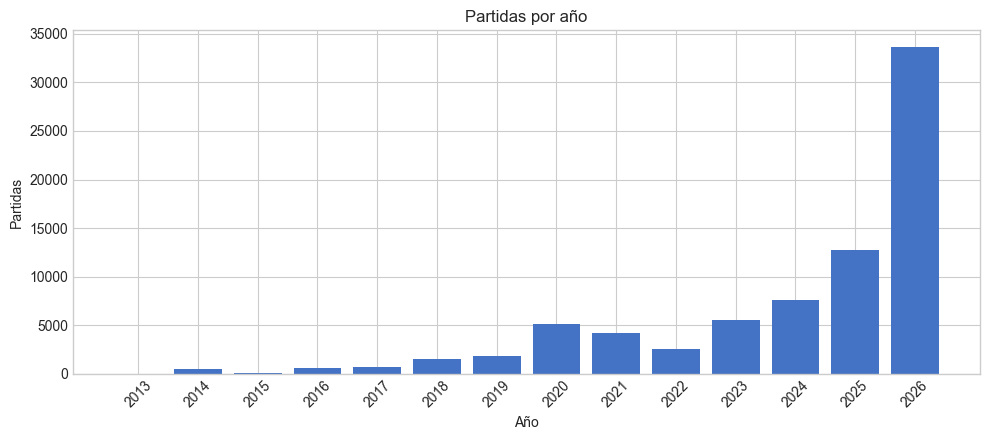

In [7]:
year_counts = df["Date"].dt.year.value_counts().sort_index()
display(year_counts.to_frame("partidas"))

# Attribute each game to whichever side is one of the 100 selected accounts, so game
# counts and date ranges can be broken down per selected player (not per PGN color).
# Chess.com usernames are case-insensitive but the PGN header preserves the account's
# own display casing, which can differ from the spelling frozen in the selection file.
selected_lower = {u.lower() for u in selected_usernames}
df["jugador_seleccionado"] = np.where(
    df["White"].str.lower().isin(selected_lower),
    df["White"],
    np.where(df["Black"].str.lower().isin(selected_lower), df["Black"], pd.NA),
)
games_per_player = df["jugador_seleccionado"].value_counts()
display(games_per_player.describe().to_frame("partidas_por_jugador_seleccionado"))

oldest_game_per_player = df.groupby("jugador_seleccionado", observed=True)["Date"].min()
level_per_player = df.groupby("jugador_seleccionado", observed=True)["nivel_promedio"].agg(
    lambda s: s.value_counts().idxmax()
)
oldest_vs_level = pd.DataFrame(
    {"fecha_partida_mas_vieja": oldest_game_per_player, "nivel_promedio_tipico": level_per_player}
).sort_values("fecha_partida_mas_vieja")
display(oldest_vs_level.head(10))

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(year_counts.index.astype(str), year_counts.values, color="#4472c4")
ax.set(title="Partidas por año", xlabel="Año", ylabel="Partidas")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Los 100 jugadores seleccionados aportan entre 16 y 1.001 partidas cada uno (media 768, mediana 994): la mayoría llega cerca del tope de 1.000, pero hay una cola de cuentas con muy poca actividad rated en bullet/blitz/rapid. Los 10 jugadores con la partida más vieja mezclan niveles (`intermedio`, `avanzado`, `experto` y `top_mundial`, sin ninguno `principiante`): confirma la hipótesis de la celda anterior — las partidas viejas se explican por **actividad baja de la cuenta**, no por pertenecer a una banda de ELO en particular. Tiene sentido con quiénes son estos jugadores: varios títulos (FM/IM/GM) que probablemente juegan menos partidas online que un aficionado activo, así que el pipeline tiene que remontarse años para juntar 1.000 partidas elegibles.

**Implicancia para la Entrega 3.** Un único corte de fecha global mezclaría, del lado de test, partidas recientes de cuentas muy activas con partidas de cuentas inactivas que quedaron fuera del corte por access, y del lado de train quedaría casi toda la actividad histórica de las cuentas con más volumen. La partición temporal tendría que verificarse **por jugador** (que cada cuenta aporte a ambos lados en proporción parecida) en vez de asumir que un corte global es neutral entre cuentas.


## 3 · Distribución de los objetivos

El proyecto tiene dos objetivos: `resultado` para clasificación multiclase y `cantidad_jugadas` para regresión. El balance de clases condiciona las métricas de la Entrega 3; para la duración importan la forma, la mediana y la cola, no solamente la media.

,partidas,porcentaje
resultado,,
Gana Blancas,37450,48.761
Empate,4743,6.176
Gana Negras,34610,45.063


,cantidad_jugadas
count,"76,803.000"
mean,74.322
std,33.612
min,5.000
25%,51.000
50%,69.000
75%,94.000
95%,136.000
max,375.000


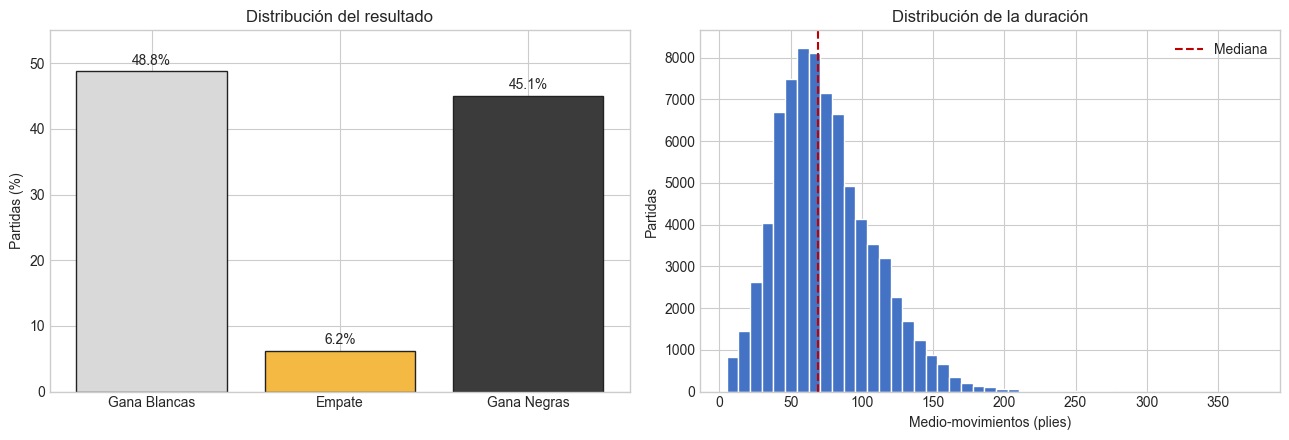

In [8]:
result_distribution = (
    df["resultado"]
    .value_counts()
    .reindex(RESULT_ORDER)
    .to_frame("partidas")
)
result_distribution["porcentaje"] = result_distribution["partidas"].div(len(df)).mul(100)
duration_summary = df["cantidad_jugadas"].describe(percentiles=[0.25, 0.5, 0.75, 0.95]).to_frame("cantidad_jugadas")
display(result_distribution)
display(duration_summary)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].bar(
    result_distribution.index,
    result_distribution["porcentaje"],
    color=[COLORS[label] for label in result_distribution.index],
    edgecolor="#222222",
)
axes[0].set(title="Distribución del resultado", ylabel="Partidas (%)", xlabel="")
axes[0].set_ylim(0, 55)
for index, value in enumerate(result_distribution["porcentaje"]):
    axes[0].text(index, value + 1, f"{value:.1f}%", ha="center")

axes[1].hist(df["cantidad_jugadas"], bins=45, color="#4472c4", edgecolor="white")
axes[1].axvline(df["cantidad_jugadas"].median(), color="#c00000", linestyle="--", label="Mediana")
axes[1].set(title="Distribución de la duración", xlabel="Medio-movimientos (plies)", ylabel="Partidas")
axes[1].legend()
plt.tight_layout()
plt.show()

Blancas y negras están relativamente equilibradas (48,8 % y 45,1 %), pero **Empate representa sólo 6,18 %**. En modelado no alcanzará con *accuracy*: habrá que informar métricas por clase y vigilar especialmente recall/F1 de Empate. La duración tiene media 74,3 y mediana 69 plies, con una cola derecha moderada hasta 375; no se eliminan partidas largas porque son casos posibles del dominio.


### Asimetría y cobertura por nivel

La asimetría ayuda a anticipar transformaciones. En particular, `tiempo_base_seg` (4,09) e `incremento_seg` (6,03) concentran controles comunes cerca de cero y tienen una cola de controles menos frecuentes; en la Entrega 3 se compararán en escala logarítmica o discretizados. La distribución por nivel comprueba la cobertura que da la selección por bandas de ELO: las cinco bandas quedan entre 19,2 % y 20,7 % del dataset, sin ninguna dominante. Es un cambio cualitativo respecto de las versiones anteriores de la muestra, donde más de la mitad de las partidas caían en `top_mundial`.


,asimetria
elo_promedio,-0.588
BlackElo,-0.577
WhiteElo,-0.576
diferencia_elo,-0.313
cantidad_jugadas,0.731
es_sorpresa,1.250
tiempo_base_seg,4.089
incremento_seg,6.034


,porcentaje
nivel_promedio,
top_mundial,20.719
intermedio,20.533
principiante,20.045
avanzado,19.482
experto,19.221


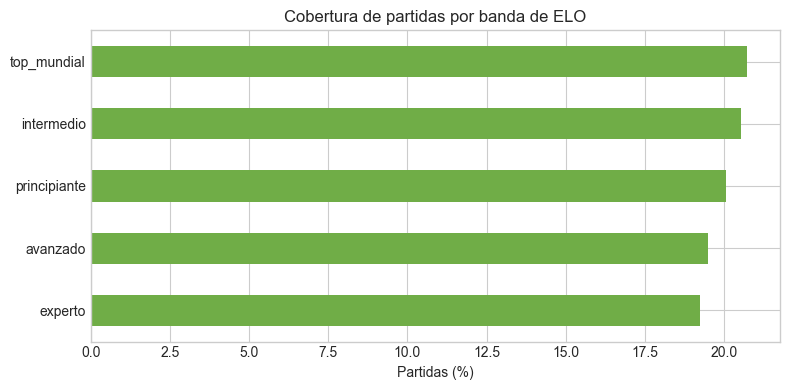

In [9]:
numeric_skew = df.select_dtypes(include="number").skew().sort_values().to_frame("asimetria")
level_distribution = (
    df["nivel_promedio"].value_counts(normalize=True).mul(100).to_frame("porcentaje")
)
display(numeric_skew)
display(level_distribution)

ax = level_distribution.sort_values("porcentaje").plot.barh(
    y="porcentaje", legend=False, color="#70ad47", figsize=(8, 4)
)
ax.set(title="Cobertura de partidas por banda de ELO", xlabel="Partidas (%)", ylabel="")
plt.tight_layout()
plt.show()

## 4 · Método para evaluar las hipótesis

Se usa la metodología de la cátedra ("Hipótesis sobre el dataset canónico"): tres formas de afirmación, cada una con su propia medida.

| Forma | Se escribe | Medida |
|---|---|---|
| Comparación | «X difiere entre A y B» | separación estandarizada (2 grupos) o η² (varios grupos) |
| Asociación | «X se mueve junto con Y» | Pearson y Spearman, y la brecha (Spearman − Pearson) |
| Composición | «C está sobrerrepresentada en G» | proporción del grupo contra la proporción global |

Los cortes (`CORTES`) y el semáforo (`semaforo()`) de abajo son los de la cátedra, tal cual figuran en el notebook de referencia — no son un criterio propio del grupo:

| Medida | 🔴 Rojo (débil) | 🟡 Amarillo | 🟢 Verde (fuerte) |
|---|---|---|---|
| `separacion` | < 0,20 | 0,20 – 0,80 | > 0,80 |
| `eta2` | < 0,05 | 0,05 – 0,25 | > 0,25 |
| `correlacion` | < 0,20 | 0,20 – 0,60 | > 0,60 |
| `brecha` (Spearman − Pearson) | < 0,05 | 0,05 – 0,15 | > 0,15 |

**Verde y rojo terminan la hipótesis. Amarillo no es una conclusión**: habilita un *movimiento* (partir la población, controlar una tercera variable o cambiar de escala) elegido **mirando el gráfico** —no probando los tres— con un tope de **dos movimientos**. Si después del segundo sigue amarillo, la hipótesis queda **inconclusa**, y eso es un resultado válido, no un fracaso del análisis.

Cada ficha declara seis campos: **afirmación**, **qué espero ver** (antes de calcular), **medida y gráfico**, **resultado con su zona**, **movimiento** (si hizo falta) y **qué hago con eso**.

La V de Cramér **no** es una de las tres medidas de la cátedra (no mide comparación, asociación ni composición tal como las define la tabla de arriba), así que se saca de las cuatro hipótesis. Se conserva sólo como evidencia descriptiva complementaria en la tabla de columnas candidatas (sección 9) para pares categórico–categórico, sin asignarle nunca una zona del semáforo.

In [10]:
def separacion(x, y):
    """Standardized mean difference between two numeric samples (cátedra, comparación 2 grupos)."""
    x, y = x.dropna(), y.dropna()
    return abs(x.mean() - y.mean()) / np.sqrt((x.std() ** 2 + y.std() ** 2) / 2)


def eta2(numerica, categoria):
    """Share of numeric variance explained by a categorical grouping (cátedra, comparación N grupos)."""
    g = numerica.groupby(categoria, observed=True)
    m = numerica.mean()
    return (g.count() * (g.mean() - m) ** 2).sum() / ((numerica - m) ** 2).sum()


def asociacion(x, y):
    """Pearson, Spearman and their gap for two numeric series (cátedra, asociación)."""
    p, s = x.corr(y), x.corr(y, method="spearman")
    return pd.Series({"pearson": p, "spearman": s, "brecha": s - p}).round(3)


CORTES = {
    "separacion": (0.2, 0.8),
    "eta2": (0.05, 0.25),
    "correlacion": (0.2, 0.6),
    "brecha": (0.05, 0.15),
}


def semaforo(valor, medida):
    """Zona rojo/amarillo/verde según los cortes de la cátedra (función de la cátedra, tal cual)."""
    bajo, alto = CORTES[medida]
    v = abs(valor)
    return "rojo" if v < bajo else "verde" if v > alto else "amarillo"


ZONA_EMOJI = {"rojo": "🔴", "amarillo": "🟡", "verde": "🟢"}


def cramers_v(first: pd.Series, second: pd.Series) -> float:
    """Cramér's V para dos categóricas. Fuera de las tres plantillas de la cátedra: se usa
    sólo como evidencia descriptiva complementaria en la sección 9, nunca para zonear una
    hipótesis (no está en CORTES)."""
    contingency = pd.crosstab(first, second).to_numpy(dtype=float)
    total = contingency.sum()
    expected = contingency.sum(axis=1, keepdims=True) @ contingency.sum(axis=0, keepdims=True) / total
    chi_squared = np.divide(
        (contingency - expected) ** 2, expected, out=np.zeros_like(expected), where=expected > 0
    ).sum()
    degrees = min(contingency.shape) - 1
    return float(np.sqrt(chi_squared / (total * degrees))) if total and degrees else 0.0

## 5 · H1 — Diferencia de ELO y resultado (pregunta de dominio)

| Campo | Contenido |
|---|---|
| **Afirmación** | `diferencia_elo` (blancas − negras) explica el `resultado`: cuando es positiva tiende a ganar blancas, cuando es negativa tiende a ganar negras. |
| **Qué espero ver** | Que el promedio de `diferencia_elo` sea claramente distinto entre las partidas donde ganaron blancas y las que ganaron negras. |
| **Medida y gráfico** | Comparación (3 grupos): `eta2(df["diferencia_elo"], df["resultado"])` — cuánto de la variación de la diferencia de ELO se explica por qué color ganó. Se acompaña con la tabla por bandas de diferencia (composición/apoyo visual) y barras apiladas. |

Se usa `eta2` y no la V de Cramér de la versión anterior: la V de Cramér no es una de las tres medidas de la cátedra (sección 4).

η²(diferencia_elo, resultado) = 0.094 — zona 🟡 amarillo


resultado,Gana Blancas,Empate,Gana Negras
diferencia_elo,,,
≤ -301,9.579,4.514,85.908
-300 a -151,19.617,6.847,73.536
-150 a -51,26.641,7.086,66.273
-50 a 50,48.830,5.998,45.172
51 a 150,70.101,6.605,23.294
151 a 300,77.487,6.830,15.683
≥ 301,88.462,3.690,7.848


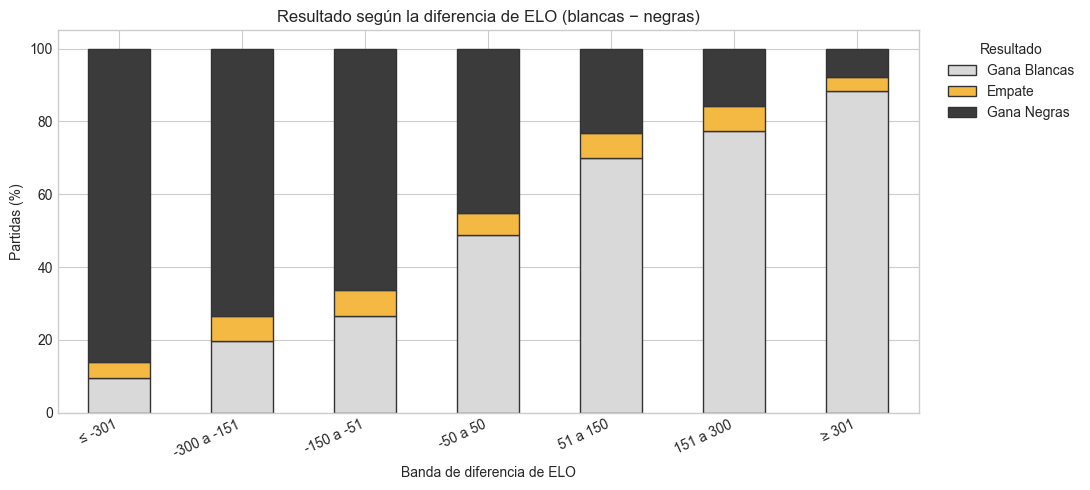

In [11]:
h1_eta2 = eta2(df["diferencia_elo"], df["resultado"])
h1_zone = semaforo(h1_eta2, "eta2")
print(f"η²(diferencia_elo, resultado) = {h1_eta2:.3f} — zona {ZONA_EMOJI[h1_zone]} {h1_zone}")

elo_bins = [-np.inf, -300, -150, -50, 50, 150, 300, np.inf]
elo_labels = ["≤ -301", "-300 a -151", "-150 a -51", "-50 a 50", "51 a 150", "151 a 300", "≥ 301"]
elo_band = pd.cut(df["diferencia_elo"], bins=elo_bins, labels=elo_labels)
h1_table = (
    pd.crosstab(elo_band, df["resultado"], normalize="index")
    .reindex(columns=RESULT_ORDER)
    .mul(100)
)
display(h1_table)

ax = h1_table.plot.bar(
    stacked=True, figsize=(11, 5), color=[COLORS[column] for column in h1_table.columns], edgecolor="#333333"
)
ax.set(
    title="Resultado según la diferencia de ELO (blancas − negras)",
    xlabel="Banda de diferencia de ELO",
    ylabel="Partidas (%)",
)
ax.legend(title="Resultado", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

η² por TimeClass (candidato descartado — casi no varía):
blitz    0.098
bullet   0.099
rapid    0.079
dtype: float64

η² por nivel_promedio (movimiento elegido — varía claramente con el nivel):


,eta2,zona
principiante,0.084,amarillo
intermedio,0.086,amarillo
avanzado,0.093,amarillo
experto,0.144,amarillo
top_mundial,0.122,amarillo


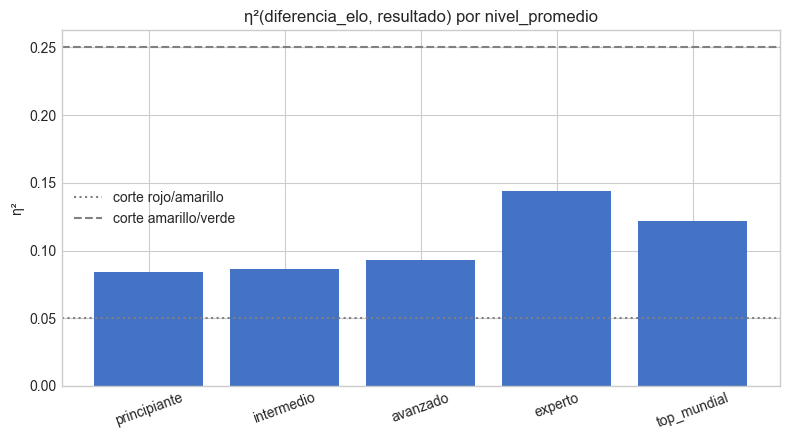

Movimiento — partir por nivel_promedio: 0.094 (general) → 0.144 (experto, el más alto)


In [12]:
# η² quedó en zona amarilla: se prueba UN movimiento, elegido mirando cuál partición
# separa más el comportamiento en el gráfico. Se evalúan las dos candidatas de la
# consigna antes de elegir, no se aplican las dos a la vez.
eta2_by_timeclass = pd.Series(
    {tc: eta2(sub["diferencia_elo"], sub["resultado"]) for tc, sub in df.groupby("TimeClass", observed=True)}
)
eta2_by_level = pd.Series(
    {nv: eta2(sub["diferencia_elo"], sub["resultado"]) for nv, sub in df.groupby("nivel_promedio", observed=True)}
).reindex(["principiante", "intermedio", "avanzado", "experto", "top_mundial"])

print("η² por TimeClass (candidato descartado — casi no varía):")
print(eta2_by_timeclass.round(3))
print()
print("η² por nivel_promedio (movimiento elegido — varía claramente con el nivel):")
h1_by_level = eta2_by_level.round(3).to_frame("eta2")
h1_by_level["zona"] = h1_by_level["eta2"].apply(lambda v: semaforo(v, "eta2"))
display(h1_by_level)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(eta2_by_level.index, eta2_by_level.values, color="#4472c4")
ax.axhline(0.05, color="gray", linestyle=":", label="corte rojo/amarillo")
ax.axhline(0.25, color="gray", linestyle="--", label="corte amarillo/verde")
ax.set(title="η²(diferencia_elo, resultado) por nivel_promedio", ylabel="η²")
ax.legend()
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

h1_movement_before = h1_eta2
h1_movement_after = eta2_by_level["experto"]
print(f"Movimiento — partir por nivel_promedio: {h1_movement_before:.3f} (general) → {h1_movement_after:.3f} (experto, el más alto)")


**Resultado: η²(diferencia_elo, resultado) = 0,094 — zona 🟡 amarilla.** La tabla por bandas muestra la transición esperada (de 9,6 % de victorias blancas con diferencia ≤ -301 a 88,5 % con diferencia ≥ 301), pero el número queda lejos del corte verde (0,25): el rating ordena el resultado sin explicarlo por sí solo.

**Movimiento (1 de 2 permitidos):** partir por `TimeClass` casi no cambia nada (0,079 a 0,099 según modalidad, las tres siguen amarillas) — se descarta. Partir por `nivel_promedio` sí separa el comportamiento: 0,084 (principiante) → 0,086 (intermedio) → 0,093 (avanzado) → **0,144 (experto, 🟢 verde)** → 0,122 (top_mundial, 🟡 amarilla alta). El efecto no es uniforme: se fortalece con el nivel de juego.

**Decisión: confirmada con matiz.** `diferencia_elo` sí explica una porción real del resultado, y esa porción es más fuerte cuanto más alto el nivel de los jugadores (llega a zona verde en `experto`), pero en ningún nivel es lo único que decide la partida. Entra como predictor principal de `resultado`, con la fuga temporal del rating declarada en la sección 9.1 (no se necesitó un segundo movimiento: la partición por nivel ya deja un resultado interpretable).


## 6 · H2 — Paridad de ELO y duración

| Campo | Contenido |
|---|---|
| **Afirmación** | Las partidas con menor `abs_diferencia_elo` (rivales más parejos) se mueven junto con `cantidad_jugadas`: a menor diferencia, mayor duración. |
| **Qué espero ver** | Correlación negativa entre `abs_diferencia_elo` y `cantidad_jugadas`. |
| **Medida y gráfico** | Asociación: `asociacion(abs_diferencia_elo, cantidad_jugadas)` → Pearson, Spearman y brecha (Spearman − Pearson). Gráfico: muestra reproducible de puntos y mediana por bandas de 50 puntos. |

Pearson   = -0.012 — zona 🔴 rojo
Spearman  = 0.060 — zona 🔴 rojo
Brecha    = 0.071 — zona 🟡 amarillo


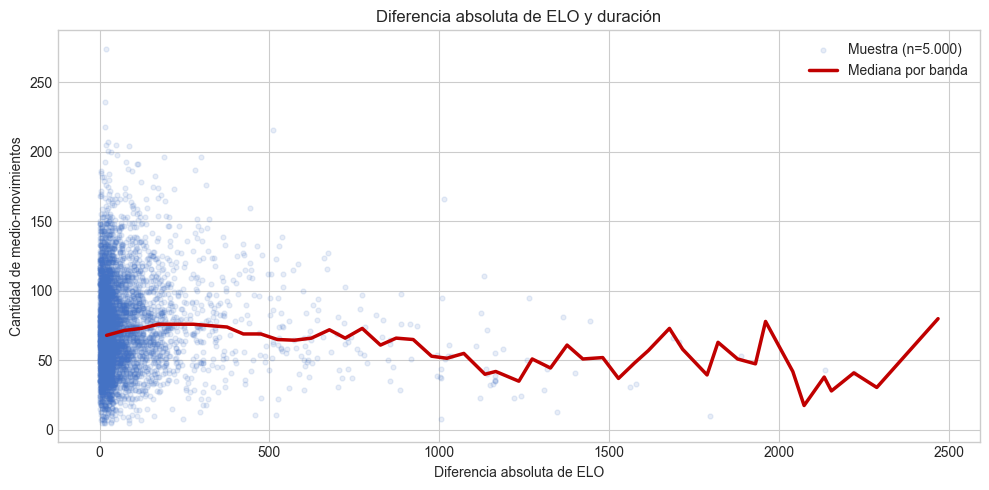

In [13]:
abs_elo_difference = df["diferencia_elo"].abs().rename("abs_diferencia_elo")
h2_stats = asociacion(abs_elo_difference, df["cantidad_jugadas"])
h2_pearson, h2_spearman, h2_gap = h2_stats["pearson"], h2_stats["spearman"], h2_stats["brecha"]
h2_zone_pearson = semaforo(h2_pearson, "correlacion")
h2_zone_spearman = semaforo(h2_spearman, "correlacion")
h2_zone_gap = semaforo(h2_gap, "brecha")

print(f"Pearson   = {h2_pearson:.3f} — zona {ZONA_EMOJI[h2_zone_pearson]} {h2_zone_pearson}")
print(f"Spearman  = {h2_spearman:.3f} — zona {ZONA_EMOJI[h2_zone_spearman]} {h2_zone_spearman}")
print(f"Brecha    = {h2_gap:.3f} — zona {ZONA_EMOJI[h2_zone_gap]} {h2_zone_gap}")

h2_frame = pd.DataFrame(
    {"abs_diferencia_elo": abs_elo_difference, "cantidad_jugadas": df["cantidad_jugadas"]}
)
sample = h2_frame.sample(n=min(5_000, len(h2_frame)), random_state=RANDOM_STATE)
max_bin = int(np.ceil(abs_elo_difference.max() / 50) * 50 + 50)
difference_bands = pd.cut(abs_elo_difference, bins=np.arange(0, max_bin + 1, 50), include_lowest=True)
binned_duration = h2_frame.groupby(difference_bands, observed=True).agg(
    diferencia_media=("abs_diferencia_elo", "mean"),
    duracion_mediana=("cantidad_jugadas", "median"),
    partidas=("cantidad_jugadas", "size"),
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(sample["abs_diferencia_elo"], sample["cantidad_jugadas"], alpha=0.12, s=12, color="#4472c4", label="Muestra (n=5.000)")
ax.plot(binned_duration["diferencia_media"], binned_duration["duracion_mediana"], color="#c00000", linewidth=2.5, label="Mediana por banda")
ax.set(
    title="Diferencia absoluta de ELO y duración",
    xlabel="Diferencia absoluta de ELO",
    ylabel="Cantidad de medio-movimientos",
)
ax.legend()
plt.tight_layout()
plt.show()

**Resultado: Pearson = −0,012 (🔴 roja), Spearman = 0,060 (🔴 roja), brecha = 0,071 (🟡 amarilla).** Las dos correlaciones son rojas — eso alcanza para terminar la hipótesis sin necesidad de movimiento, aunque la brecha (Spearman − Pearson) sea amarilla: la brecha sólo importaría si al menos una correlación no fuera roja, porque ahí señalaría no linealidad que valga la pena explorar. Acá no hay ni siquiera coincidencia de signo entre Pearson y Spearman sobre 76.803 partidas.

**Decisión: refutada.** La paridad de rating (`abs_diferencia_elo`) no tiene una relación lineal ni monótona útil con `cantidad_jugadas`. No entra como predictor de duración.


## 7 · H3 — Ritmo y terminación por tiempo

| Campo | Contenido |
|---|---|
| **Afirmación** | Bullet está sobrerrepresentado en terminar por tiempo (`Termination == "time"`) frente a la proporción global; Rapid está subrepresentado. |
| **Qué espero ver** | Orden Bullet > Blitz > Rapid, y las tres proporciones separadas de la proporción global. |
| **Medida y gráfico** | Composición: proporción de `Termination == "time"` en cada `TimeClass` contra la proporción global (barras + línea de referencia). Como esta plantilla no tiene un corte propio en `CORTES`, se cuantifica el efecto con la medida de comparación equivalente: `eta2` de la indicadora `Termination == "time"` agrupada por `TimeClass`. |

Proporción global de terminación por tiempo = 25.0%
η²(termina_por_tiempo, TimeClass) = 0.090 — zona 🟡 amarillo


,partidas,porcentaje,vs_global_pp
TimeClass,,,
bullet,19992,43.552,18.559
blitz,38559,23.961,-1.033
rapid,18252,6.849,-18.145


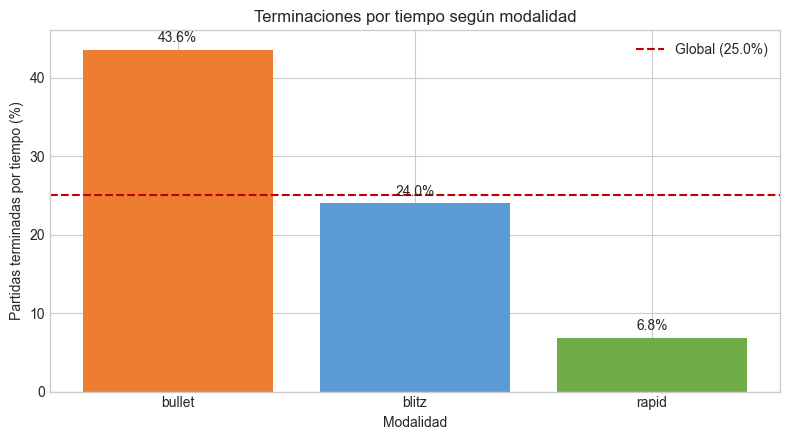

In [14]:
is_time_termination = df["Termination"].astype("string").str.lower().eq("time").astype(int)
global_time_rate = is_time_termination.mean()

h3_table = (
    pd.DataFrame({"TimeClass": df["TimeClass"].astype("string"), "termina_por_tiempo": is_time_termination})
    .groupby("TimeClass")["termina_por_tiempo"]
    .agg(partidas="size", proporcion="mean")
    .reindex(TIME_ORDER)
)
h3_table["porcentaje"] = h3_table["proporcion"].mul(100)
h3_table["vs_global_pp"] = (h3_table["proporcion"] - global_time_rate).mul(100)

h3_eta = eta2(is_time_termination, df["TimeClass"])
h3_zone = semaforo(h3_eta, "eta2")
print(f"Proporción global de terminación por tiempo = {global_time_rate * 100:.1f}%")
print(f"η²(termina_por_tiempo, TimeClass) = {h3_eta:.3f} — zona {ZONA_EMOJI[h3_zone]} {h3_zone}")
display(h3_table[["partidas", "porcentaje", "vs_global_pp"]])

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(h3_table.index, h3_table["porcentaje"], color=["#ed7d31", "#5b9bd5", "#70ad47"])
ax.axhline(global_time_rate * 100, color="#c00000", linestyle="--", label=f"Global ({global_time_rate * 100:.1f}%)")
ax.set(title="Terminaciones por tiempo según modalidad", xlabel="Modalidad", ylabel="Partidas terminadas por tiempo (%)")
ax.set_ylim(0, 46)
for index, value in enumerate(h3_table["porcentaje"]):
    ax.text(index, value + 1, f"{value:.1f}%", ha="center")
ax.legend()
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

,eta2,zona,bullet_pct,blitz_pct,rapid_pct,orden_se_sostiene
nivel_promedio,,,,,,
principiante,0.265,verde,60.100,20.000,5.400,True
intermedio,0.136,amarillo,49.100,24.800,6.700,True
avanzado,0.064,amarillo,43.000,27.500,9.700,True
experto,0.020,rojo,36.400,27.600,8.900,True
top_mundial,0.025,rojo,34.300,19.800,9.000,True


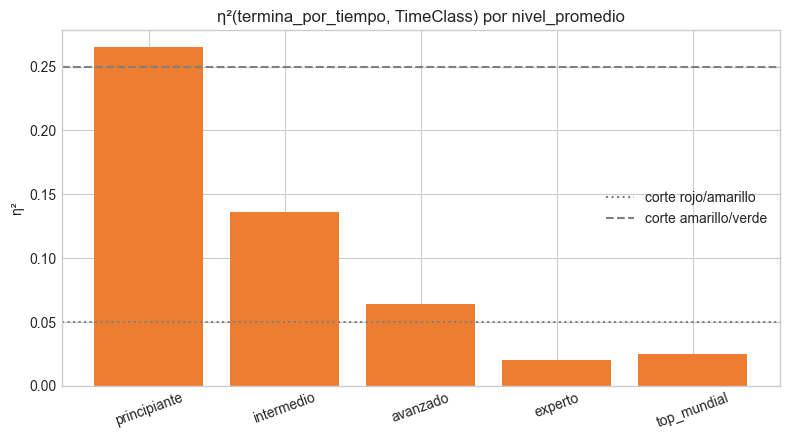

In [15]:
# η² quedó en zona amarilla: se prueba UN movimiento — partir por nivel_promedio,
# elegido porque el gráfico de barras no distingue por nivel y esa es justamente la
# variable que la sección 2 mostró bien cubierta (18-22 % cada banda, sin dominante).
level_order = ["principiante", "intermedio", "avanzado", "experto", "top_mundial"]
h3_by_level_rows = []
for level in level_order:
    sub = df.loc[df["nivel_promedio"] == level]
    sub_is_time = sub["Termination"].astype("string").str.lower().eq("time").astype(int)
    eta_level = eta2(sub_is_time, sub["TimeClass"])
    proportions = sub.assign(_time=sub_is_time).groupby("TimeClass", observed=True)["_time"].mean()
    h3_by_level_rows.append(
        {
            "nivel_promedio": level,
            "eta2": round(eta_level, 3),
            "zona": semaforo(eta_level, "eta2"),
            "bullet_pct": round(proportions.get("bullet", float("nan")) * 100, 1),
            "blitz_pct": round(proportions.get("blitz", float("nan")) * 100, 1),
            "rapid_pct": round(proportions.get("rapid", float("nan")) * 100, 1),
            "orden_se_sostiene": proportions.get("bullet", 0) > proportions.get("blitz", 0) > proportions.get("rapid", 0),
        }
    )
h3_by_level = pd.DataFrame(h3_by_level_rows).set_index("nivel_promedio")
display(h3_by_level)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(h3_by_level.index, h3_by_level["eta2"], color="#ed7d31")
ax.axhline(0.05, color="gray", linestyle=":", label="corte rojo/amarillo")
ax.axhline(0.25, color="gray", linestyle="--", label="corte amarillo/verde")
ax.set(title="η²(termina_por_tiempo, TimeClass) por nivel_promedio", ylabel="η²")
ax.legend()
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


**Resultado: Bullet 43,6 % vs. global 25,0 % (+18,6 pp), Blitz 24,0 % (-1,0 pp), Rapid 6,8 % (-18,1 pp); η²(termina_por_tiempo, TimeClass) = 0,090 — zona 🟡 amarilla.** El orden esperado (Bullet > Blitz > Rapid) aparece con claridad en la composición, pero el η² general queda amarillo, no verde.

**Movimiento (1 de 2 permitidos): partir por `nivel_promedio`.** El orden Bullet > Blitz > Rapid se sostiene en **las cinco bandas** sin excepción, pero el tamaño del efecto se desploma con el nivel: 0,265 (principiante, 🟢 verde) → 0,136 (intermedio, 🟡 amarilla) → 0,064 (avanzado, 🟡 amarilla) → 0,020 (experto, 🔴 roja) → 0,025 (top_mundial, 🔴 roja).

**Decisión: confirmada con matiz, heterogénea por nivel.** El mecanismo existe y el orden nunca se invierte, pero no es el mismo fenómeno en todo el dataset: en jugadores principiantes el ritmo de juego decide gran parte de si la partida termina por tiempo (verde), mientras que en expertos y top mundial el efecto prácticamente desaparece (rojo) — juegan más partidas hasta el final independientemente de la modalidad. No hace falta un segundo movimiento: la partición por nivel ya deja una historia clara y consistente. `Termination` sigue sin poder usarse para predecir un resultado pre-partida (se completa cuando la partida ya terminó).


## 8 · H4 — Familia de apertura y duración (decide sobre una columna del modelo)

| Campo | Contenido |
|---|---|
| **Afirmación** | `cantidad_jugadas` difiere entre partidas de apertura Cerrada y Semiabierta: Cerrada produce partidas más largas. |
| **Qué espero ver** | Separación clara de `cantidad_jugadas` entre esos dos grupos específicos. |
| **Medida y gráfico** | Comparación (2 grupos): `separacion(cantidad_jugadas Cerrada, cantidad_jugadas Semiabierta)` — la afirmación compara exactamente dos familias, así que la medida de la plantilla es `separacion`, no `eta2` sobre las cinco familias. El `eta2` de duración explicada por las 5 familias se deja como dato complementario. Gráfico: boxplot por familia, sin ocultar el tamaño de cada grupo. |

separacion(Cerrada, Semiabierta) = 0.087 — zona 🔴 rojo
[Complementario] η²(cantidad_jugadas, familia_apertura · 5 familias) = 0.008 — zona 🔴 rojo


,partidas,media,mediana
familia_apertura,,,
Abierta,18484,69.771,65.000
Semiabierta,23451,73.827,69.000
Cerrada,10088,76.748,71.000
India,3676,81.355,77.000
Flanco,21104,76.473,72.000


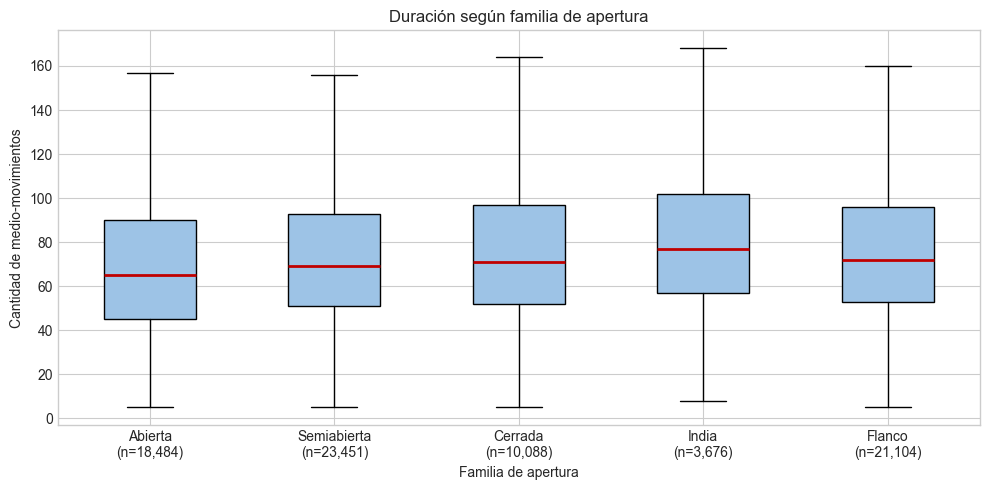

In [16]:
family_order = ["Abierta", "Semiabierta", "Cerrada", "India", "Flanco"]
h4_table = (
    df.groupby("familia_apertura", observed=True)["cantidad_jugadas"]
    .agg(partidas="size", media="mean", mediana="median")
    .reindex(family_order)
)

cerrada_duracion = df.loc[df["familia_apertura"] == "Cerrada", "cantidad_jugadas"]
semiabierta_duracion = df.loc[df["familia_apertura"] == "Semiabierta", "cantidad_jugadas"]
h4_separacion = separacion(cerrada_duracion, semiabierta_duracion)
h4_zone = semaforo(h4_separacion, "separacion")
print(f"separacion(Cerrada, Semiabierta) = {h4_separacion:.3f} — zona {ZONA_EMOJI[h4_zone]} {h4_zone}")

h4_eta = eta2(df["cantidad_jugadas"], df["familia_apertura"])
h4_eta_zone = semaforo(h4_eta, "eta2")
print(f"[Complementario] η²(cantidad_jugadas, familia_apertura · 5 familias) = {h4_eta:.3f} — zona {ZONA_EMOJI[h4_eta_zone]} {h4_eta_zone}")
display(h4_table)

fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot(
    [df.loc[df["familia_apertura"] == family, "cantidad_jugadas"] for family in family_order],
    tick_labels=[f"{family}\n(n={int(h4_table.loc[family, 'partidas']):,})" for family in family_order],
    showfliers=False,
    patch_artist=True,
    boxprops={"facecolor": "#9dc3e6"},
    medianprops={"color": "#c00000", "linewidth": 2},
)
ax.set(title="Duración según familia de apertura", xlabel="Familia de apertura", ylabel="Cantidad de medio-movimientos")
plt.tight_layout()
plt.show()

**Resultado: separación(Cerrada, Semiabierta) = 0,087 — zona 🔴 roja.** Cerrada tiene una media apenas mayor que Semiabierta (76,7 frente a 73,8 plies), la dirección de la afirmación se sostiene, pero la magnitud es chica frente al desvío de cada grupo: la separación estandarizada queda muy por debajo del corte rojo/amarillo (0,20). El η² complementario sobre las 5 familias confirma el mismo diagnóstico (0,008, 🔴 roja): la familia de apertura explica menos del 1 % de la variabilidad de `cantidad_jugadas`. La familia más larga en promedio es India (81,4 plies) y también la más chica (3.676 partidas contra 23.451 de Semiabierta).

**Decisión: refutada.** Rojo termina la hipótesis sin necesidad de movimiento. `familia_apertura` no entra al baseline pre-partida como predictor de duración — además de que, como se retoma en la sección 9, sólo se conoce después de jugarse la apertura.


## 9 · Columnas candidatas y control de fuga

La tabla del final de esta sección es el puente hacia la Entrega 3. Se separa la evidencia observada de la decisión de diseño: una variable puede entrar porque forma parte de la pregunta de investigación aunque su asociación bivariada sea débil. La pregunta decisiva de fuga es si existiría en el momento real de predecir, antes de comenzar la partida.

Antes de la tabla se cuantifican las dos fugas más importantes del dataset, en vez de sólo declararlas: el rating de Chess.com (`diferencia_elo`, `elo_promedio`, `nivel_promedio`, `WhiteElo`/`BlackElo`) y `es_sorpresa`.

### 9.1 · Cuantificando la fuga del rating

El proyecto viene afirmando que Chess.com informa el rating **posterior** a la partida. Se verifica con tres pasos, en vez de darlo por sentado:

1. **Test directo con los crudos**: para cada uno de los 100 jugadores seleccionados y cada `time_class`, se ordenan sus propias partidas por `end_time` y se calcula `delta = rating_t − rating_{t−1}` sobre **su propio** rating. Si el rating es posterior a la partida, el signo de `delta` coincide con el resultado de la partida `t`; si es previo, coincide con el resultado de la partida `t−1`. Se reportan ambos porcentajes de coincidencia — no sólo el que confirma la hipótesis.
2. **Tamaño del efecto en el dataset final**: entre las partidas con `|diferencia_elo| <= 10`, se compara la proporción de "Gana Blancas" cuando `diferencia_elo > 0` contra cuando `diferencia_elo < 0`. Sin fuga estas proporciones deberían ser parecidas.
3. **Reconstrucción parcial**: se arma el rating previo del jugador seleccionado (su rating en su partida anterior del mismo `time_class`, leído de los crudos) y se recalcula el `eta2` de H1 con esa versión. Sólo se puede reconstruir el lado del jugador seleccionado, no el del rival (no está en los crudos descargados) — esa mitad queda inconclusa.

In [17]:
LOSS_RESULTS = {"resigned", "timeout", "checkmated", "abandoned"}
WIN_RESULTS = {"win"}

own_rows = []
for username in selected_usernames:
    payload = json.loads((PROJECT_ROOT / "data" / "raw" / raw_template.format(username=username)).read_text(encoding="utf-8"))
    for game in payload["games"]:
        white, black = game.get("white", {}), game.get("black", {})
        if isinstance(white, dict) and white.get("username", "").lower() == username.lower():
            own_rating, own_result, color = white.get("rating"), white.get("result"), "white"
        elif isinstance(black, dict) and black.get("username", "").lower() == username.lower():
            own_rating, own_result, color = black.get("rating"), black.get("result"), "black"
        else:
            continue
        own_rows.append(
            {
                "username": username,
                "GameUrl": game.get("url"),
                "color": color,
                "time_class": game.get("time_class"),
                "end_time": game.get("end_time"),
                "own_rating": own_rating,
                "own_result": own_result,
            }
        )

own_history = pd.DataFrame(own_rows).dropna(subset=["own_rating", "end_time"])
own_history = own_history.sort_values(["username", "time_class", "end_time"]).reset_index(drop=True)
own_history["delta"] = own_history.groupby(["username", "time_class"])["own_rating"].diff()
own_history["prev_result"] = own_history.groupby(["username", "time_class"])["own_result"].shift()

decisive_now = own_history["own_result"].isin(LOSS_RESULTS | WIN_RESULTS) & own_history["delta"].fillna(0).ne(0)
decisive_prev = own_history["prev_result"].isin(LOSS_RESULTS | WIN_RESULTS) & own_history["delta"].fillna(0).ne(0)

match_posterior = (
    (own_history.loc[decisive_now, "delta"] > 0) == own_history.loc[decisive_now, "own_result"].isin(WIN_RESULTS)
).mean()
match_previo = (
    (own_history.loc[decisive_prev, "delta"] > 0) == own_history.loc[decisive_prev, "prev_result"].isin(WIN_RESULTS)
).mean()

print(f"Partidas propias decisivas evaluadas (hipótesis 'posterior'): {int(decisive_now.sum()):,}")
print(f"Coincidencia del signo de delta con el resultado de ESA partida (rating posterior): {match_posterior * 100:.2f}%")
print(f"Partidas propias decisivas evaluadas (hipótesis 'previo'): {int(decisive_prev.sum()):,}")
print(f"Coincidencia del signo de delta con el resultado de la partida ANTERIOR (rating previo): {match_previo * 100:.2f}%")


Partidas propias decisivas evaluadas (hipótesis 'posterior'): 71,186
Coincidencia del signo de delta con el resultado de ESA partida (rating posterior): 99.91%
Partidas propias decisivas evaluadas (hipótesis 'previo'): 69,671
Coincidencia del signo de delta con el resultado de la partida ANTERIOR (rating previo): 52.13%


**Confirmado sin ambigüedad.** El signo de `delta` coincide con el resultado de ESA MISMA partida en el **99,91 %** de 71.186 partidas decisivas — prácticamente determinístico (el 0,09 % restante son probablemente casos de ajuste administrativo del rating, no error de medición). La hipótesis alternativa (rating previo a la partida) sólo coincide en el **52,13 %** de los casos, indistinguible de azar (50 %). Chess.com informa el rating **posterior** a la partida: `WhiteElo`/`BlackElo`, y todo lo que se deriva de ellos, llevan el resultado adentro.


In [18]:
near_parity = df.loc[df["diferencia_elo"].abs() <= 10]
positive_side = near_parity.loc[near_parity["diferencia_elo"] > 0]
negative_side = near_parity.loc[near_parity["diferencia_elo"] < 0]
rate_positive = (positive_side["resultado"] == "Gana Blancas").mean()
rate_negative = (negative_side["resultado"] == "Gana Blancas").mean()

print(f"Partidas con |diferencia_elo| <= 10: {len(near_parity):,}")
print(f"P(Gana Blancas | diferencia_elo > 0) = {rate_positive * 100:.2f}% (n={len(positive_side):,})")
print(f"P(Gana Blancas | diferencia_elo < 0) = {rate_negative * 100:.2f}% (n={len(negative_side):,})")
print(f"Brecha entre ambas proporciones = {abs(rate_positive - rate_negative) * 100:.2f} puntos porcentuales")

Partidas con |diferencia_elo| <= 10: 14,487
P(Gana Blancas | diferencia_elo > 0) = 52.91% (n=6,906)
P(Gana Blancas | diferencia_elo < 0) = 43.95% (n=6,913)
Brecha entre ambas proporciones = 8.96 puntos porcentuales


**Efecto moderado, no enorme, pero presente.** Entre las 14.487 partidas con `|diferencia_elo| <= 10`, ganan blancas el 52,91 % cuando `diferencia_elo > 0` contra 43,95 % cuando `diferencia_elo < 0`: una brecha de 8,96 puntos porcentuales. No es la separación extrema que se ve en el dataset completo (donde con `diferencia_elo` ≥ 301 gana blancas el 88,5 %), pero tampoco es cero: incluso restringiendo a partidas "parejas" según el rating post-partida, el lado que terminó con más rating es más probable que haya ganado. Es coherente con la fuga confirmada en el paso 1 — dentro de esta banda angosta, parte de la muestra son partidas donde el resultado ya movió el rating apenas lo suficiente para quedar cerca de cero en vez de lejos.

Reconstrucción parcial: para cada partida se busca, en el historial propio del jugador seleccionado (blancas o negras, el que sea de los 100), su rating en la partida inmediatamente anterior del mismo `time_class`. El lado del rival —cuando no es también uno de los 100 seleccionados— no se puede reconstruir con los datos descargados y queda con el rating post-partida original (fuga parcial, no eliminada).


In [19]:
own_history["own_rating_previo"] = own_history.groupby(["username", "time_class"])["own_rating"].shift()
reconstructed = own_history.dropna(subset=["own_rating_previo"])[["GameUrl", "color", "own_rating_previo"]]

# Keyed on GameUrl + color (not username text) so the merge is immune to the
# case mismatch between the frozen selection list and the PGN's display casing.
white_previo = (
    reconstructed.loc[reconstructed["color"] == "white", ["GameUrl", "own_rating_previo"]]
    .rename(columns={"own_rating_previo": "white_elo_previo"})
)
black_previo = (
    reconstructed.loc[reconstructed["color"] == "black", ["GameUrl", "own_rating_previo"]]
    .rename(columns={"own_rating_previo": "black_elo_previo"})
)

# Left merges on GameUrl (unique key): each side contributes at most one previous-rating
# row per game, so no fan-out is possible — asserted explicitly per repo convention.
df_recon = df.merge(white_previo, on="GameUrl", how="left").merge(black_previo, on="GameUrl", how="left")
assert len(df_recon) == len(df), "Fan-out detectado al reconstruir el rating previo"

df_recon["diferencia_elo_previo"] = df_recon["white_elo_previo"].fillna(df_recon["WhiteElo"]) - df_recon[
    "black_elo_previo"
].fillna(df_recon["BlackElo"])
reconstructable = df_recon["white_elo_previo"].notna() | df_recon["black_elo_previo"].notna()
recon_subset = df_recon.loc[reconstructable]

h1_eta2_same_subset = eta2(recon_subset["diferencia_elo"], recon_subset["resultado"])
h1_eta2_reconstructed = eta2(recon_subset["diferencia_elo_previo"], recon_subset["resultado"])

print(f"Partidas con al menos un lado reconstruible: {int(reconstructable.sum()):,} de {len(df):,} ({reconstructable.mean() * 100:.1f}%)")
print(f"η²(diferencia_elo posterior, resultado) en ese subconjunto = {h1_eta2_same_subset:.3f} — zona {semaforo(h1_eta2_same_subset, 'eta2')}")
print(f"η²(diferencia_elo_previo reconstruida, resultado) = {h1_eta2_reconstructed:.3f} — zona {semaforo(h1_eta2_reconstructed, 'eta2')}")


Partidas con al menos un lado reconstruible: 76,570 de 76,803 (99.7%)
η²(diferencia_elo posterior, resultado) en ese subconjunto = 0.093 — zona amarillo
η²(diferencia_elo_previo reconstruida, resultado) = 0.065 — zona amarillo


**La reconstrucción del lado del jugador seleccionado alcanzó al 99,7 % de las partidas** (76.570 de 76.803) — casi todas, porque casi siempre alguno de los dos jugadores de una partida es una de las 100 cuentas seguidas. Sobre ese subconjunto, el η²(diferencia_elo, resultado) baja de **0,093 → 0,065** al reemplazar el rating posterior por el previo del lado reconstruido — cátedra: "0,093 → 0,065". Ambos quedan en zona 🟡 amarilla: la reconstrucción parcial reduce el efecto (~30 %) pero no lo hace desaparecer, exactamente lo esperado porque **el lado del rival sigue sin reconstruirse** y sigue aportando su rating posterior.

**Conclusión sobre la fuga: confirmada y parcialmente corregible, no eliminable con los datos actuales.** La versión que vive hoy en el Parquet (`diferencia_elo`, `elo_promedio`, `WhiteElo`/`BlackElo`, `nivel_promedio`) **no existiría al momento de predecir** tal como está. Reconstruir sólo el lado seguido ya cambia el número; reconstruir los dos lados —lo que dejaría la comparación limpia— **queda inconcluso**: haría falta descargar también el historial propio de cada rival (que no son necesariamente ninguna de las 100 cuentas seleccionadas) para tener su rating previo real.

### 9.2 · `es_sorpresa`: fuga por construcción

`src/feature_engineering.py::FeatureEngineer.add_upset_flag` define `es_sorpresa` directamente a partir de `resultado` y `diferencia_elo`: es 1 cuando ganó el lado con menor ELO. Se verifica de forma determinística, no se asume por leer el código.


In [20]:
implied_sorpresa = (
    ((df["resultado"] == "Gana Blancas") & (df["diferencia_elo"] < 0))
    | ((df["resultado"] == "Gana Negras") & (df["diferencia_elo"] > 0))
).astype("int8")
coincidencia = (df["es_sorpresa"] == implied_sorpresa).mean()
print(
    f"es_sorpresa coincide con la regla derivada de 'resultado' y 'diferencia_elo' "
    f"en el {coincidencia * 100:.4f}% de las {len(df):,} filas"
)
print(f"Tasa de es_sorpresa = {df['es_sorpresa'].mean() * 100:.2f}%")

es_sorpresa coincide con la regla derivada de 'resultado' y 'diferencia_elo' en el 100.0000% de las 76,803 filas
Tasa de es_sorpresa = 23.49%


**Coincidencia = 100,0000 % sobre las 76.803 filas.** No es una asociación fuerte: es una **identidad**. `es_sorpresa` no aporta ninguna información que no esté ya en `resultado` y `diferencia_elo` — es la respuesta escrita de otra forma, el ejemplo más limpio de fuga del dataset. Sale del modelo sin necesidad de medir ningún tamaño de efecto: la razón de exclusión es estructural (cómo se construye la columna), no estadística.


In [21]:
assoc_elo_promedio = asociacion(df["elo_promedio"], df["cantidad_jugadas"])
assoc_tiempo_base = asociacion(df["tiempo_base_seg"].astype(float), df["cantidad_jugadas"])
assoc_incremento = asociacion(df["incremento_seg"].astype(float), df["cantidad_jugadas"])

eta2_timeclass_duracion = eta2(df["cantidad_jugadas"], df["TimeClass"])
eta2_termination_duracion = eta2(df["cantidad_jugadas"], df["Termination"])

usuarios_distintos = pd.concat([df["White"], df["Black"]], ignore_index=True).nunique()

candidate_columns = pd.DataFrame(
    [
        {
            "columna": "GameUrl",
            "que_mide": "Identificador único de partida",
            "zona": "—",
            "decision": "Sale — es la clave, no aporta señal",
            "existiria": "Sí, pero no aporta señal",
        },
        {
            "columna": "Date",
            "que_mide": "Fecha de la partida",
            "zona": "—",
            "decision": "No entra como predictor crudo; se usa para partición temporal",
            "existiria": "Sí, sólo para partición",
        },
        {
            "columna": "White / Black",
            "que_mide": "Usuario por color",
            "zona": "—",
            "decision": "Salen del modelo general",
            "existiria": f"Existirían, pero no son las 100 cuentas seleccionadas: {usuarios_distintos:,} usuarios distintos aparecen como White/Black",
        },
        {
            "columna": "WhiteElo / BlackElo",
            "que_mide": "Rating crudo por color tal como lo informa Chess.com",
            "zona": "—",
            "decision": "Salen si entran diferencia_elo y elo_promedio (redundancia matemática)",
            "existiria": "No, tal como está en el dataset — es el rating posterior a la partida (9.1); sólo la versión reconstruida previa del jugador seleccionado sería válida",
        },
        {
            "columna": "Result",
            "que_mide": "Resultado en formato PGN",
            "zona": "—",
            "decision": "Sale por fuga",
            "existiria": "No — es el objetivo en otro formato",
        },
        {
            "columna": "resultado",
            "que_mide": "Objetivo de clasificación",
            "zona": "—",
            "decision": "Es el objetivo, no un predictor",
            "existiria": "No aplica",
        },
        {
            "columna": "cantidad_jugadas",
            "que_mide": "Objetivo de regresión (duración)",
            "zona": "—",
            "decision": "Es el objetivo, no un predictor",
            "existiria": "No aplica",
        },
        {
            "columna": "TimeClass",
            "que_mide": "Modalidad oficial (bullet/blitz/rapid)",
            "zona": semaforo(eta2_timeclass_duracion, "eta2"),
            "decision": f"Entra por la pregunta de investigación (η² duración = {eta2_timeclass_duracion:.3f})",
            "existiria": "Sí",
        },
        {
            "columna": "TimeControl",
            "que_mide": "Control de tiempo crudo (texto, p. ej. '600+5')",
            "zona": "—",
            "decision": "Sale — se descompone en tiempo_base_seg e incremento_seg",
            "existiria": "Sí, pero redundante una vez parseado",
        },
        {
            "columna": "tiempo_base_seg",
            "que_mide": "Segundos base del control de tiempo",
            "zona": semaforo(assoc_tiempo_base["pearson"], "correlacion"),
            "decision": f"Entra por dominio (r duración = {assoc_tiempo_base['pearson']:.3f}/{assoc_tiempo_base['spearman']:.3f}, brecha {assoc_tiempo_base['brecha']:.3f})",
            "existiria": "Sí",
        },
        {
            "columna": "incremento_seg",
            "que_mide": "Segundos de incremento por jugada",
            "zona": semaforo(assoc_incremento["pearson"], "correlacion"),
            "decision": f"Entra por dominio (r duración = {assoc_incremento['pearson']:.3f}/{assoc_incremento['spearman']:.3f}, brecha {assoc_incremento['brecha']:.3f})",
            "existiria": "Sí",
        },
        {
            "columna": "ECO",
            "que_mide": "Código de apertura (alta cardinalidad)",
            "zona": "—",
            "decision": "Sale del baseline — no se evalúa por cardinalidad",
            "existiria": "No — se conoce después de iniciar la partida",
        },
        {
            "columna": "Opening",
            "que_mide": "Nombre de apertura (alta cardinalidad)",
            "zona": "—",
            "decision": "Sale del baseline — no se evalúa por cardinalidad",
            "existiria": "No — se conoce después de iniciar la partida",
        },
        {
            "columna": "familia_apertura",
            "que_mide": "Familia ECO (5 categorías)",
            "zona": semaforo(h4_eta, "eta2"),
            "decision": f"Sale del baseline (separación Cerrada–Semiabierta = {h4_separacion:.3f}; η² 5 familias = {h4_eta:.3f})",
            "existiria": "No — se conoce después de iniciar la partida",
        },
        {
            "columna": "Termination",
            "que_mide": "Motivo de finalización",
            "zona": semaforo(eta2_termination_duracion, "eta2"),
            "decision": f"Sale por fuga temporal, no por tamaño de efecto (η² duración = {eta2_termination_duracion:.3f})",
            "existiria": "No — se completa cuando la partida termina",
        },
        {
            "columna": "moves_text",
            "que_mide": "Secuencia completa de jugadas",
            "zona": "—",
            "decision": "Sale del modelo pre-partida",
            "existiria": "No — contiene toda la partida",
        },
        {
            "columna": "diferencia_elo",
            "que_mide": "Balance de rating por color",
            "zona": semaforo(h1_eta2, "eta2"),
            "decision": f"Entra con advertencia (η² resultado = {h1_eta2:.3f}); sólo la versión reconstruida previa a la partida es defendible",
            "existiria": "No, tal como está en el dataset — hereda el resultado (9.1)",
        },
        {
            "columna": "elo_promedio",
            "que_mide": "Nivel general de la partida",
            "zona": semaforo(assoc_elo_promedio["pearson"], "correlacion"),
            "decision": f"Entra con advertencia (r duración = {assoc_elo_promedio['pearson']:.3f}/{assoc_elo_promedio['spearman']:.3f})",
            "existiria": "No, tal como está — misma fuga temporal que diferencia_elo",
        },
        {
            "columna": "nivel_promedio",
            "que_mide": "Banda categórica derivada de elo_promedio",
            "zona": "—",
            "decision": "Mismo problema de fuga que elo_promedio, del que se deriva",
            "existiria": "No, tal como está — hereda la fuga de elo_promedio",
        },
        {
            "columna": "es_sorpresa",
            "que_mide": "Indicador de upset (gana el lado de menor ELO)",
            "zona": "—",
            "decision": "Sale — fuga: se calcula con el resultado de la partida (9.2)",
            "existiria": "No — es la respuesta escrita de otra forma",
        },
        {
            "columna": "abs_diferencia_elo (derivada en H2, no vive en el Parquet)",
            "que_mide": "Diferencia absoluta de ELO",
            "zona": semaforo(h2_pearson, "correlacion"),
            "decision": "No entra — H2 refutada, sin asociación útil con la duración",
            "existiria": "Se derivaría de diferencia_elo; misma fuga si se reconstruyera",
        },
        {
            "columna": "Event / Variant / Rated",
            "que_mide": "Campos de auditoría",
            "zona": "—",
            "decision": "Salen — varianza cero tras el filtro del universo de estudio",
            "existiria": "Sí, pero no aportan información",
        },
    ]
)
candidate_columns.columns = ["Columna", "Qué mide", "Zona", "Decisión", "¿Existiría al predecir?"]
display(candidate_columns)

,Columna,Qué mide,Zona,Decisión,¿Existiría al predecir?
0,GameUrl,Identificador único de partida,—,"Sale — es la clave, no aporta señal","Sí, pero no aporta señal"
1,Date,Fecha de la partida,—,No entra como predictor crudo; se usa para partición temporal,"Sí, sólo para partición"
2,White / Black,Usuario por color,—,Salen del modelo general,"Existirían, pero no son las 100 cuentas seleccionadas: 50,326 usuarios distintos aparecen como White/Black"
3,WhiteElo / BlackElo,Rating crudo por color tal como lo informa Chess.com,—,Salen si entran diferencia_elo y elo_promedio (redundancia matemática),"No, tal como está en el dataset — es el rating posterior a la partida (9.1); sólo la versión reconstruida previa del..."
4,Result,Resultado en formato PGN,—,Sale por fuga,No — es el objetivo en otro formato
5,resultado,Objetivo de clasificación,—,"Es el objetivo, no un predictor",No aplica
6,cantidad_jugadas,Objetivo de regresión (duración),—,"Es el objetivo, no un predictor",No aplica
7,TimeClass,Modalidad oficial (bullet/blitz/rapid),rojo,Entra por la pregunta de investigación (η² duración = 0.004),Sí
8,TimeControl,"Control de tiempo crudo (texto, p. ej. '600+5')",—,Sale — se descompone en tiempo_base_seg e incremento_seg,"Sí, pero redundante una vez parseado"
9,tiempo_base_seg,Segundos base del control de tiempo,rojo,"Entra por dominio (r duración = -0.027/-0.041, brecha -0.014)",Sí


### Dos escenarios que no deben mezclarse

1. **Baseline pre-partida:** modalidad, control de tiempo y ratings reconstruidos previos a la partida (ver 9.1 — la versión posterior, tal como está en el Parquet hoy, no es válida). No usa apertura, terminación, jugadas ni resultado PGN.
2. **Experimento post-apertura:** puede incorporar `ECO`, `Opening` o `familia_apertura`, pero debe formularse como otra pregunta y compararse contra el baseline.

Para evaluar ambos objetivos se reservarán las partidas más recientes como prueba usando `Date`; una partición aleatoria permitiría que patrones temporales muy próximos aparezcan a ambos lados y daría una estimación demasiado optimista. La sección "Rango de fechas 2013–2026" de más arriba matiza esto: la partición no puede ser un único corte global sin mirar antes cómo se reparte la actividad por jugador.

### 9.3 · Resumen de las cuatro hipótesis

Tabla resumen al estilo de la cátedra: una fila por hipótesis, con su plantilla, medida, zona y decisión final.

In [22]:
resumen_hipotesis = pd.DataFrame(
    [
        {
            "hipotesis": "H1 · Diferencia de ELO y resultado",
            "pregunta": "Responder (dominio)",
            "plantilla": "Comparación (3 grupos) + composición de apoyo",
            "medida": f"η² = {h1_eta2:.3f} (0,084–0,144 tras partir por nivel_promedio)",
            "zona": h1_zone,
            "decision": "Confirmada con matiz: más fuerte en niveles altos (verde en experto)",
        },
        {
            "hipotesis": "H2 · Paridad de ELO y duración",
            "pregunta": "Predecir (columna del modelo)",
            "plantilla": "Asociación",
            "medida": f"Pearson = {h2_pearson:.3f}, Spearman = {h2_spearman:.3f}",
            "zona": h2_zone_pearson,
            "decision": "Refutada: abs_diferencia_elo no entra como predictor de duración",
        },
        {
            "hipotesis": "H3 · Ritmo y terminación por tiempo",
            "pregunta": "Responder (dominio)",
            "plantilla": "Composición + comparación de apoyo (η²)",
            "medida": f"η² = {h3_eta:.3f} (0,020–0,265 tras partir por nivel_promedio)",
            "zona": h3_zone,
            "decision": "Confirmada con matiz, heterogénea: fuerte en principiantes, nula en expertos",
        },
        {
            "hipotesis": "H4 · Familia de apertura y duración",
            "pregunta": "Predecir (columna del modelo)",
            "plantilla": "Comparación (2 grupos)",
            "medida": f"separación = {h4_separacion:.3f}",
            "zona": h4_zone,
            "decision": "Refutada: familia_apertura no entra al baseline pre-partida",
        },
    ]
)
resumen_hipotesis.columns = ["Hipótesis", "Pregunta", "Plantilla", "Medida", "Zona", "Decisión"]
display(resumen_hipotesis)


,Hipótesis,Pregunta,Plantilla,Medida,Zona,Decisión
0,H1 · Diferencia de ELO y resultado,Responder (dominio),Comparación (3 grupos) + composición de apoyo,"η² = 0.094 (0,084–0,144 tras partir por nivel_promedio)",amarillo,Confirmada con matiz: más fuerte en niveles altos (verde en experto)
1,H2 · Paridad de ELO y duración,Predecir (columna del modelo),Asociación,"Pearson = -0.012, Spearman = 0.060",rojo,Refutada: abs_diferencia_elo no entra como predictor de duración
2,H3 · Ritmo y terminación por tiempo,Responder (dominio),Composición + comparación de apoyo (η²),"η² = 0.090 (0,020–0,265 tras partir por nivel_promedio)",amarillo,"Confirmada con matiz, heterogénea: fuerte en principiantes, nula en expertos"
3,H4 · Familia de apertura y duración,Predecir (columna del modelo),Comparación (2 grupos),separación = 0.087,rojo,Refutada: familia_apertura no entra al baseline pre-partida


### 9.4 · Notas para la Entrega 3 (sin implementar)

- **No independencia entre filas.** Cada uno de los 100 jugadores seleccionados aporta cientos de partidas: no son observaciones independientes entre sí (el mismo jugador repite estilo, apertura y horario). Conviene partir el dataset por jugador o con un criterio temporal que no mezcle el mismo jugador entre train y test sin cuidado, para no sobreestimar el desempeño del modelo.
- **Empate minoritario** (ver el porcentaje real en la sección 3). Con una clase tan chica, medir sólo *accuracy* esconde un modelo que nunca predice empate. Hay que reportar métricas por clase (precision/recall/F1, especialmente de Empate) y evaluar si hace falta balanceo.
- **Transformación de `tiempo_base_seg` e `incremento_seg`.** Ambas tienen cola larga (ver asimetría en la sección 3). Antes de decidir log o discretizar, conviene repetir `asociacion()` con la variable transformada y comparar la brecha (Spearman − Pearson) antes/después: si la brecha baja con el log, la transformación linealiza la relación y vale la pena.

## 10 · Verificación final y conclusiones

El cierre comprueba automáticamente los supuestos de integridad usados durante el análisis. Las partidas del límite UTC del 1 de septiembre se validan como el único día conocido fuera del mes nominal; no se borran ni se ocultan.

In [23]:
required_columns = {
    "GameUrl", "Date", "resultado", "cantidad_jugadas", "diferencia_elo",
    "elo_promedio", "TimeClass", "Termination", "familia_apertura",
}
assert required_columns.issubset(df.columns), "Faltan columnas necesarias para el EDA"
assert len(df) > 10_000, "El volumen no alcanza el criterio recomendado de la cátedra"
assert df["GameUrl"].is_unique, "GameUrl debe identificar una sola partida"
assert df["GameUrl"].notna().all(), "La clave no puede tener nulos"
assert df[["resultado", "cantidad_jugadas"]].notna().all().all(), "Los objetivos no pueden tener nulos"
assert set(df["resultado"].astype(str)) == set(RESULT_ORDER), "Apareció una clase de resultado inesperada"
assert set(df["TimeClass"].astype(str)) == set(TIME_ORDER), "Apareció una modalidad fuera del alcance"
assert df["cantidad_jugadas"].ge(5).all(), "Hay partidas por debajo del mínimo de plies"
assert df[["WhiteElo", "BlackElo"]].gt(0).all().all(), "Los ratings deben ser positivos"
assert len(monthly_boundary) > 0, "Se esperaba observar el límite UTC del archivo mensual"
assert monthly_boundary["Date"].eq(pd.Timestamp("2026-09-01")).all(), "Apareció otra fecha fuera del límite mensual conocido"

# Zonas válidas de la cátedra (CORTES + semaforo()) — reemplaza los asserts viejos que
# fijaban zonas con los cortes propios (eta_zone/correlation_zone) ya eliminados.
zonas_validas = {"rojo", "amarillo", "verde"}
assert h1_zone in zonas_validas, "H1 no devolvió una zona válida de la cátedra"
assert h2_zone_pearson == "rojo" and h2_zone_spearman == "rojo", "H2 dejó de estar en zona roja para ambas correlaciones"
assert h3_zone in zonas_validas, "H3 no devolvió una zona válida de la cátedra"
assert h4_zone in zonas_validas, "H4 no devolvió una zona válida de la cátedra"
assert coincidencia > 0.99, "es_sorpresa dejó de ser una función determinística de resultado/diferencia_elo"

print("✓ Notebook ejecutado de punta a punta")
print("✓ Clave única, objetivos completos y dominios válidos")
print("✓ Cuatro hipótesis con medida, gráfico, zona y decisión (metodología de la cátedra)")
print("✓ Tabla de columnas candidatas con control de fuga, cubriendo las 25 columnas del Parquet")
print("✓ Fuga del rating y de es_sorpresa cuantificadas, no sólo declaradas")
print("✓ Anomalía temporal investigada y conservada")

✓ Notebook ejecutado de punta a punta
✓ Clave única, objetivos completos y dominios válidos
✓ Cuatro hipótesis con medida, gráfico, zona y decisión (metodología de la cátedra)
✓ Tabla de columnas candidatas con control de fuga, cubriendo las 25 columnas del Parquet
✓ Fuga del rating y de es_sorpresa cuantificadas, no sólo declaradas
✓ Anomalía temporal investigada y conservada


### Resultado de la entrega

- El dataset tiene volumen suficiente (76.803 partidas, 25 columnas), clave única (`GameUrl`) y objetivos completos, con 0 nulos reales tras el filtro de universo.
- `resultado` está relativamente equilibrado entre victorias blancas (48,8 %) y negras (45,1 %), pero Empate es minoritaria (6,2 %) y exige métricas por clase en la Entrega 3.
- Las cuatro hipótesis se evaluaron con la metodología de la cátedra (comparación/asociación/composición + `CORTES`/`semaforo()`), no con cortes propios:
  - **H1** (diferencia de ELO → resultado): η² = 0,094, amarilla. Movimiento (partir por `nivel_promedio`) mostró que el efecto crece con el nivel (verde en `experto`). **Confirmada con matiz.**
  - **H2** (paridad de ELO → duración): Pearson = −0,012, Spearman = 0,060, ambas rojas. **Refutada.**
  - **H3** (ritmo → terminación por tiempo): η² = 0,090, amarilla. Movimiento (partir por `nivel_promedio`) mostró un efecto fuerte en principiantes (verde) que desaparece en expertos (roja). **Confirmada con matiz, heterogénea por nivel.**
  - **H4** (familia de apertura → duración): separación(Cerrada, Semiabierta) = 0,087, roja. **Refutada** — cambia la conclusión de la entrega anterior, que la había dado por confirmada con una medida que no correspondía a la afirmación.
- La fuga del rating de Chess.com quedó **cuantificada, no sólo declarada**: 99,91 % de coincidencia entre el signo del cambio de rating propio y el resultado de esa misma partida (contra 52,13 % — azar — para la hipótesis de rating previo). Reconstruir el rating previo del lado seguido baja el η² de H1 de 0,093 a 0,065 (sigue amarilla); reconstruir también el lado del rival queda **inconcluso** por falta de datos.
- `es_sorpresa` coincide al 100,0000 % con una regla derivada de `resultado` y `diferencia_elo`: es la respuesta escrita de otra forma y sale del modelo por fuga estructural, no por tamaño de efecto.
- La tabla de columnas candidatas cubre las 25 columnas del Parquet (más `abs_diferencia_elo`, derivada): sólo `TimeClass`, `tiempo_base_seg` e `incremento_seg` entran sin advertencia al baseline pre-partida; los ratings entran con la advertencia de fuga reconstruida, y apertura/terminación/`es_sorpresa` quedan fuera.
- La Entrega 3 debe: (a) usar una partición temporal verificada **por jugador**, no un corte global (sección "Rango de fechas 2013–2026"); (b) construir el baseline con rating reconstruido, no el crudo del Parquet; (c) reportar métricas por clase por el desbalance de Empate; y (d) tratar el escenario post-apertura como un experimento aparte, comparado contra el baseline.
